In [1]:
import numpy as np

# Constants
c = 299792458    # in m
R = 474e3        # in m

# Instrument
tau_p = 2e-9        # pulse width
theta_b = 20e-6     # beam divergence in rad
sigma_theta = 2e-6  # pointing jitter in rad

# Scene
canopy_cover = 0.98
canopy_height = 20.0
sigma_h = 0.3

# Swath geometry
N = 168
swath = 1000.0
dx = swath / N
i0 = (N - 1) / 2
theta0 = 2e-3   # 2 mrad forward

idx = np.arange(N)
x = (idx - i0) * dx
theta = np.sqrt(theta0**2 + (x / R)**2)

# Photon returns 
N_veg = 6.5
N_soil = 0.3

N_c = canopy_cover * N_veg
N_g = (1 - canopy_cover) * N_soil
N_r = N_c + N_g

# Timing terms
sigma_t_ph = tau_p / np.sqrt(N_r)
sigma_t_geom = (2 * R / c) * theta_b * np.tan(theta)
sigma_t_rough = 2 * sigma_h / c
sigma_t_jitter = (2 * R / c) * sigma_theta * np.tan(theta)

sigma_t_canopy = np.sqrt(
    sigma_t_ph**2 +
    sigma_t_geom**2 +
    sigma_t_rough**2 +
    sigma_t_jitter**2
)

sigma_t_ground = np.sqrt(
    sigma_t_canopy**2 +
    (2 * canopy_height / c)**2
)

# Bias & precision
range_precision = (c / 2) * sigma_t_ground
range_bias = canopy_cover * canopy_height

# Outputs
print("\n--- Mission-level Results ---")
print(f"Mean photons per pulse      : {N_r:.2f}")
print(f"Ground photon fraction      : {N_g/N_r:.3f}")
print(f"Single-beam range precision : {range_precision[int(i0)]:.1f} m")
print(f"Systematic range bias       : {range_bias:.1f} m")

detectable = N_g / np.sqrt(N_c) > 1
print(f"Ground detectable?          : {detectable}")



--- Mission-level Results ---
Mean photons per pulse      : 6.38
Ground photon fraction      : 0.001
Single-beam range precision : 20.0 m
Systematic range bias       : 19.6 m
Ground detectable?          : False


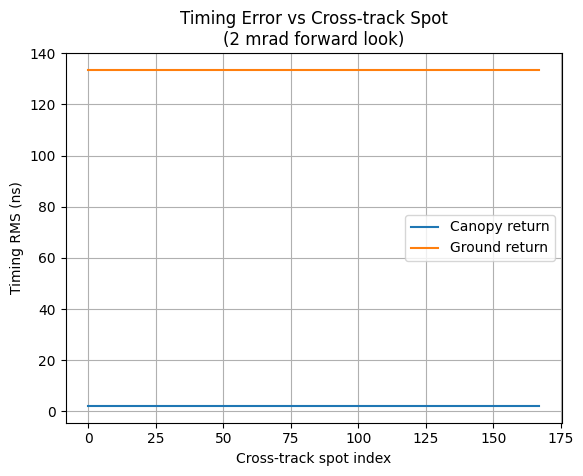

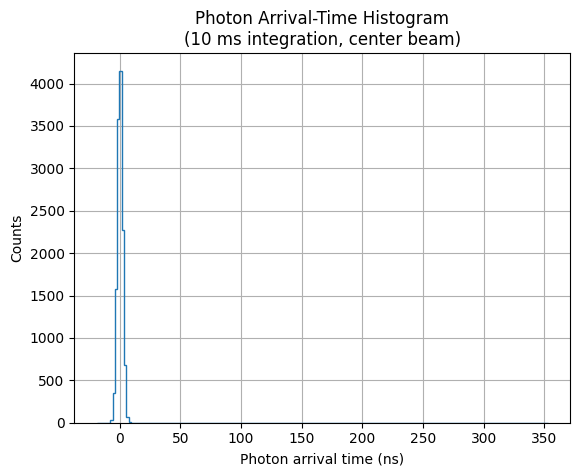


--- Histogram Interpretation ---
Pulses integrated        : 2000
Mean canopy arrival      : 0.0 ns
Mean ground arrival      : 133.4 ns
• Narrow peak = canopy-top returns
• Delayed, broad tail = ground photons
• Separation improves only with accumulation


In [2]:
# Plots of timing errors across cross-track spots and arrival-time histogram
# Gardner-based canopy vs ground model
# 474 km orbit, 2 mrad forward, 1 km swath, 168 spots
# 2 ns pulse, 200 kHz repetition rate

import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Constants
# -------------------------------
c = 299_792_458
R = 474e3

# -------------------------------
# Instrument parameters
# -------------------------------
tau_p = 2e-9                 # pulse width [s]
theta_b = 15e-6              # beam divergence [rad]
sigma_theta = 2e-6           # pointing jitter [rad]
rep_rate = 200e3             # Hz

# -------------------------------
# Scene parameters
# -------------------------------
canopy_cover = 0.98
canopy_height = 20.0         # m
sigma_h = 0.3                # m RMS

# -------------------------------
# Swath geometry
# -------------------------------
N = 168
swath = 1000.0
dx = swath / N
i0 = (N - 1) / 2
theta0 = 2e-3                # 2 mrad forward look

idx = np.arange(N)
x = (idx - i0) * dx
theta = np.sqrt(theta0**2 + (x / R)**2)

# -------------------------------
# Photon statistics (representative)
# -------------------------------
N_veg = 6.5
N_soil = 0.3

N_c = canopy_cover * N_veg
N_g = (1 - canopy_cover) * N_soil
N_r = N_c + N_g

# -------------------------------
# Timing error terms
# -------------------------------
sigma_t_ph = tau_p / np.sqrt(N_r)
sigma_t_geom = (2 * R / c) * theta_b * np.tan(theta)
sigma_t_jitter = (2 * R / c) * sigma_theta * np.tan(theta)
sigma_t_rough = 2 * sigma_h / c

sigma_t_canopy = np.sqrt(
    sigma_t_ph**2 +
    sigma_t_geom**2 +
    sigma_t_jitter**2 +
    sigma_t_rough**2
)

sigma_t_ground = np.sqrt(
    sigma_t_canopy**2 +
    (2 * canopy_height / c)**2
)

# -------------------------------
# Plot 1: Timing error across cross-track spots
# -------------------------------
plt.figure()
plt.plot(idx, sigma_t_canopy * 1e9, label="Canopy return")
plt.plot(idx, sigma_t_ground * 1e9, label="Ground return")
plt.xlabel("Cross-track spot index")
plt.ylabel("Timing RMS (ns)")
plt.title("Timing Error vs Cross-track Spot\n(2 mrad forward look)")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Arrival-time histogram simulation
# -------------------------------
# Number of pulses accumulated (~10 ms)
T_obs = 0.01
N_pulses = int(rep_rate * T_obs)

# Mean arrival times
t0 = 0.0
t_ground = 2 * canopy_height / c

# Draw photon arrivals
np.random.seed(1)

canopy_times = np.random.normal(
    t0, sigma_t_canopy[int(i0)], int(N_pulses * N_c)
)

ground_times = np.random.normal(
    t_ground, sigma_t_ground[int(i0)], int(N_pulses * N_g)
)

arrival_times = np.concatenate([canopy_times, ground_times])

# -------------------------------
# Plot 2: Arrival-time histogram
# -------------------------------
plt.figure()
plt.hist(arrival_times * 1e9, bins=200, histtype='step')
plt.xlabel("Photon arrival time (ns)")
plt.ylabel("Counts")
plt.title("Photon Arrival-Time Histogram\n(10 ms integration, center beam)")
plt.grid(True)
plt.show()

# -------------------------------
# Interpretation printout
# -------------------------------
print("\n--- Histogram Interpretation ---")
print(f"Pulses integrated        : {N_pulses}")
print(f"Mean canopy arrival      : {t0*1e9:.1f} ns")
print(f"Mean ground arrival      : {t_ground*1e9:.1f} ns")
print("• Narrow peak = canopy-top returns")
print("• Delayed, broad tail = ground photons")
print("• Separation improves only with accumulation")


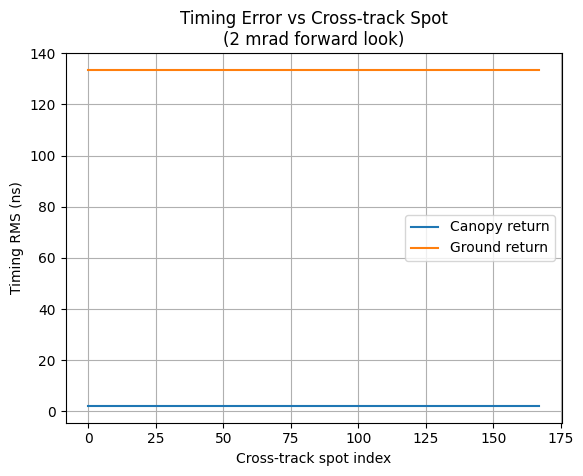

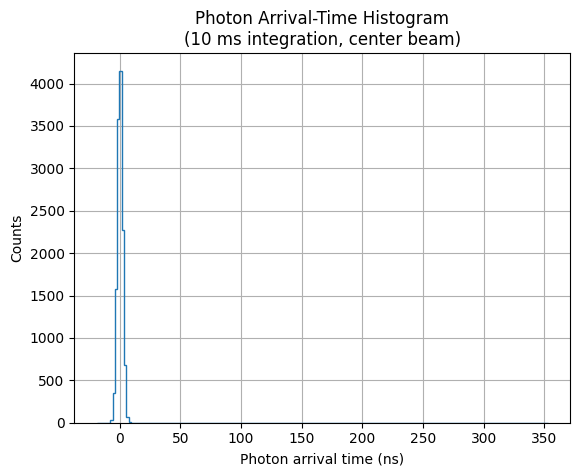


--- Histogram Interpretation ---
Pulses integrated        : 2000
Mean canopy arrival      : 0.0 ns
Mean ground arrival      : 133.4 ns
• Narrow peak = canopy-top returns
• Delayed, broad tail = ground photons
• Separation improves only with accumulation


In [3]:
# Plots of timing errors across cross-track spots and arrival-time histogram
# Gardner-based canopy vs ground model
# 474 km orbit, 2 mrad forward look, 1 km swath, 168 spots
# 2 ns pulse, 200 kHz repetition rate

import numpy as np
import matplotlib.pyplot as plt

# Constants
c = 299_792_458
R = 474e3

# Instrument parameters
tau_p = 2e-9                 # pulse width [s]
theta_b = 20e-6              # beam divergence [rad]
sigma_theta = 2e-6           # pointing jitter [rad]
rep_rate = 200e3             # Hz

# -------------------------------
# Scene parameters
# -------------------------------
canopy_cover = 0.98
canopy_height = 20.0         # m
sigma_h = 0.3                # m RMS

# -------------------------------
# Swath geometry
# -------------------------------
N = 168
swath = 1000.0
dx = swath / N
i0 = (N - 1) / 2
theta0 = 2e-3                # 2 mrad forward look

idx = np.arange(N)
x = (idx - i0) * dx
theta = np.sqrt(theta0**2 + (x / R)**2)

# -------------------------------
# Photon statistics (representative)
# -------------------------------
N_veg = 6.5
N_soil = 0.3

N_c = canopy_cover * N_veg
N_g = (1 - canopy_cover) * N_soil
N_r = N_c + N_g

# -------------------------------
# Timing error terms
# -------------------------------
sigma_t_ph = tau_p / np.sqrt(N_r)
sigma_t_geom = (2 * R / c) * theta_b * np.tan(theta)
sigma_t_jitter = (2 * R / c) * sigma_theta * np.tan(theta)
sigma_t_rough = 2 * sigma_h / c

sigma_t_canopy = np.sqrt(
    sigma_t_ph**2 +
    sigma_t_geom**2 +
    sigma_t_jitter**2 +
    sigma_t_rough**2
)

sigma_t_ground = np.sqrt(
    sigma_t_canopy**2 +
    (2 * canopy_height / c)**2
)

# -------------------------------
# Plot 1: Timing error across cross-track spots
# -------------------------------
plt.figure()
plt.plot(idx, sigma_t_canopy * 1e9, label="Canopy return")
plt.plot(idx, sigma_t_ground * 1e9, label="Ground return")
plt.xlabel("Cross-track spot index")
plt.ylabel("Timing RMS (ns)")
plt.title("Timing Error vs Cross-track Spot\n(2 mrad forward look)")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Arrival-time histogram simulation
# -------------------------------
# Number of pulses accumulated (~10 ms)
T_obs = 0.01
N_pulses = int(rep_rate * T_obs)

# Mean arrival times
t0 = 0.0
t_ground = 2 * canopy_height / c

# Draw photon arrivals
np.random.seed(1)

canopy_times = np.random.normal(
    t0, sigma_t_canopy[int(i0)], int(N_pulses * N_c)
)

ground_times = np.random.normal(
    t_ground, sigma_t_ground[int(i0)], int(N_pulses * N_g)
)

arrival_times = np.concatenate([canopy_times, ground_times])

# -------------------------------
# Plot 2: Arrival-time histogram
# -------------------------------
plt.figure()
plt.hist(arrival_times * 1e9, bins=200, histtype='step')
plt.xlabel("Photon arrival time (ns)")
plt.ylabel("Counts")
plt.title("Photon Arrival-Time Histogram\n(10 ms integration, center beam)")
plt.grid(True)
plt.show()

# -------------------------------
# Interpretation printout
# -------------------------------
print("\n--- Histogram Interpretation ---")
print(f"Pulses integrated        : {N_pulses}")
print(f"Mean canopy arrival      : {t0*1e9:.1f} ns")
print(f"Mean ground arrival      : {t_ground*1e9:.1f} ns")
print("• Narrow peak = canopy-top returns")
print("• Delayed, broad tail = ground photons")
print("• Separation improves only with accumulation")


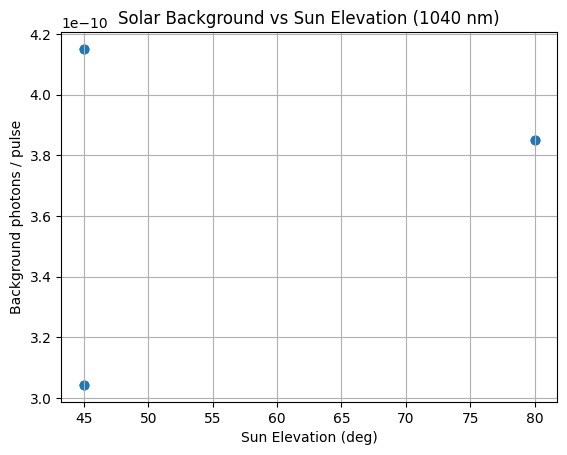

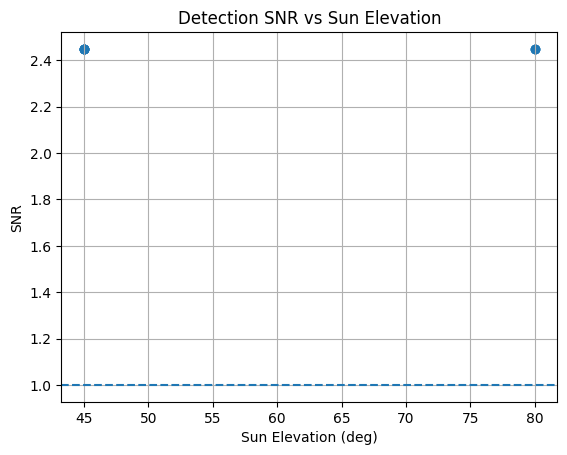

,CC_min,CC_max,Slope,Rough,CanopyH,VegRefl,VegEnh,LAI,Tatm_g,Tatm_ir,OD_g,OD_ir,SunEl,N_bg,SNR,Detectable
0,30,99,0,4,45,0.45,1.3,8,0.50,0.80,0.70,0.22,80,3.851838e-10,2.44949,True
1,30,99,15,6,35,0.45,1.3,8,0.50,0.80,0.70,0.22,80,3.851838e-10,2.44949,True
2,30,99,30,10,30,0.45,1.3,8,0.50,0.80,0.70,0.22,80,3.851838e-10,2.44949,True
3,10,99,0,4,30,0.45,1.3,5,0.85,0.98,0.16,0.02,45,4.150245e-10,2.44949,True
4,10,99,15,6,30,0.45,1.3,4,0.85,0.98,0.16,0.02,45,4.150245e-10,2.44949,True
5,10,99,30,10,20,0.45,1.3,3,0.85,0.98,0.16,0.02,45,4.150245e-10,2.44949,True
6,10,60,0,4,15,0.33,1.3,5,0.85,0.98,0.16,0.02,45,3.043513e-10,2.44949,True
7,10,60,15,6,10,0.33,1.3,4,0.85,0.98,0.16,0.02,45,3.043513e-10,2.44949,True
8,10,60,30,10,5,0.33,1.3,3,0.85,0.98,0.16,0.02,45,3.043513e-10,2.44949,True


In [4]:
# Solar background photon model vs Sun elevation using provided terrain table
# Gardner-consistent link + background formulation
# Produces background photon rate, SNR, and ground detectability

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Constants
# -------------------------------
c = 299_792_458
h = 6.626e-34
wavelength = 1040e-9
E_ph = h * c / wavelength

# Instrument / orbit
altitude = 474e3
Ar = 0.503            # receiver area [m^2]
IFOV = (10 / altitude)**2   # approx solid angle of 10 m spot
bandwidth = 2e-9      # spectral filter width [m]
rep_rate = 200e3

# Solar constants
Esun_1040 = 0.7       # W/m^2/nm (approx spectral irradiance)

# -------------------------------
# Terrain / atmosphere table
# -------------------------------
data = [
    [30,99,0,4,45,0.45,1.30,8,0.5,0.8,0.7,0.22,80],
    [30,99,15,6,35,0.45,1.30,8,0.5,0.8,0.7,0.22,80],
    [30,99,30,10,30,0.45,1.30,8,0.5,0.8,0.7,0.22,80],
    [10,99,0,4,30,0.45,1.30,5,0.85,0.98,0.16,0.02,45],
    [10,99,15,6,30,0.45,1.30,4,0.85,0.98,0.16,0.02,45],
    [10,99,30,10,20,0.45,1.30,3,0.85,0.98,0.16,0.02,45],
    [10,60,0,4,15,0.33,1.30,5,0.85,0.98,0.16,0.02,45],
    [10,60,15,6,10,0.33,1.30,4,0.85,0.98,0.16,0.02,45],
    [10,60,30,10,5,0.33,1.30,3,0.85,0.98,0.16,0.02,45]
]

cols = [
    "CC_min","CC_max","Slope","Rough","CanopyH",
    "VegRefl","VegEnh","LAI","Tatm_g","Tatm_ir","OD_g","OD_ir","SunEl"
]

df = pd.DataFrame(data, columns=cols)

# -------------------------------
# Background photon calculation
# -------------------------------
def background_photons(row):
    sun_el = np.deg2rad(row.SunEl)
    mu0 = np.sin(sun_el)

    # Surface radiance (Lambertian)
    Lsurf = (
        Esun_1040 * mu0 *
        row.VegRefl * row.VegEnh *
        row.Tatm_ir**2 / np.pi
    )

    # Power entering receiver
    Pbg = Lsurf * Ar * IFOV * bandwidth

    # Photon rate
    Nbg = Pbg / E_ph

    # Photons per pulse window (2 ns)
    return Nbg * 2e-9

df["N_bg"] = df.apply(background_photons, axis=1)

# -------------------------------
# Signal photons (representative)
# -------------------------------
N_signal = 6.0  # photons per pulse (from earlier model)

df["SNR"] = N_signal / np.sqrt(N_signal + df["N_bg"])
df["Detectable"] = df["SNR"] > 1.0

# -------------------------------
# Plot: background vs Sun elevation
# -------------------------------
plt.figure()
plt.scatter(df["SunEl"], df["N_bg"])
plt.xlabel("Sun Elevation (deg)")
plt.ylabel("Background photons / pulse")
plt.title("Solar Background vs Sun Elevation (1040 nm)")
plt.grid(True)
plt.show()

# -------------------------------
# Plot: SNR vs Sun elevation
# -------------------------------
plt.figure()
plt.scatter(df["SunEl"], df["SNR"])
plt.axhline(1.0, linestyle="--")
plt.xlabel("Sun Elevation (deg)")
plt.ylabel("SNR")
plt.title("Detection SNR vs Sun Elevation")
plt.grid(True)
plt.show()

# -------------------------------
# Display results
# -------------------------------
df


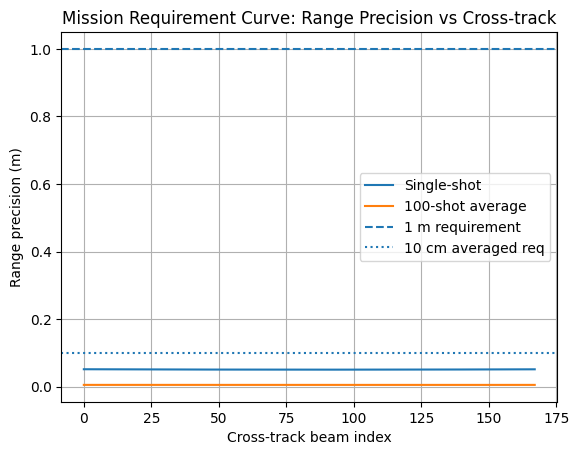

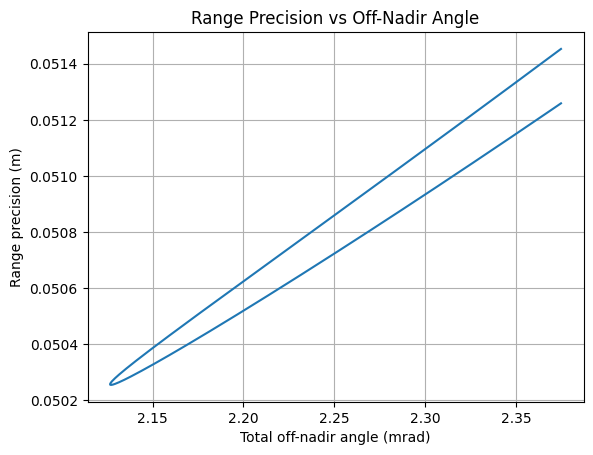


--- Mission Requirement Summary ---
Center-beam single-shot precision : 0.050 m
Center-beam 100-shot precision    : 0.005 m
Forward look angle                : 2.13 mrad
Edge off-nadir angle              : 2.37 mrad


In [5]:
# Mission requirement curves for spaceborne laser altimeter
# Gardner-consistent performance model
# -----------------------------------------------------------
# 150 µJ pulse, 2 ns width, 1040 nm
# Altitude: 474 km, forward look: 1.008 km
# Telescope diameter: 0.6 m, detector efficiency: 90%
# Beam divergence: 21 µrad
# Ground spot: 10 m
# Cross-track: 1.008 km, 168 beams, wavelength-dispersed 1035–1045 nm

import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Physical constants
# -------------------------------
c = 299_792_458
h = 6.626e-34

# -------------------------------
# Mission / instrument parameters
# -------------------------------
altitude = 474e3
pulse_energy = 150e-6
pulse_width = 2e-9
wavelength_center = 1040e-9
beam_div = 21e-6
det_eff = 0.90
tx_eff = 0.70
rx_eff = 0.90
forward_offset = 1008.0  # meters

D_telescope = 0.60
A_rx = np.pi * (D_telescope / 2)**2

# -------------------------------
# Cross-track geometry
# -------------------------------
N_beams = 168
swath = 1008.0
dx = swath / N_beams
i0 = (N_beams - 1) / 2

idx = np.arange(N_beams)
x = (idx - i0) * dx

theta_forward = forward_offset / altitude
theta_cross = x / altitude
theta_total = np.sqrt(theta_forward**2 + theta_cross**2)

# -------------------------------
# Wavelength distribution
# -------------------------------
wavelengths = np.linspace(1035e-9, 1045e-9, N_beams)

# -------------------------------
# Photon budget
# -------------------------------
E_ph = h * c / wavelengths
N_tx = pulse_energy / E_ph

rho_ground = 0.30
Tatm = 0.90

geom_factor = A_rx / (np.pi * altitude**2)

N_signal = (
    N_tx * tx_eff * rx_eff * det_eff *
    rho_ground * Tatm**2 *
    geom_factor
)

# -------------------------------
# Timing error terms (Gardner)
# -------------------------------
sigma_t_ph = pulse_width / np.sqrt(N_signal)

sigma_t_geom = (2 * altitude / c) * beam_div * np.tan(theta_total)

sigma_t_jitter = (2 * altitude / c) * (2e-6) * np.tan(theta_total)

sigma_t_total = np.sqrt(
    sigma_t_ph**2 +
    sigma_t_geom**2 +
    sigma_t_jitter**2
)

range_precision = (c / 2) * sigma_t_total

# -------------------------------
# Mission requirement curves
# -------------------------------
# Requirement examples
req_single = 1.0   # 1 m single-shot requirement
req_avg = 0.1      # 10 cm averaged requirement
N_avg = 100        # pulses averaged

range_precision_avg = range_precision / np.sqrt(N_avg)

# -------------------------------
# Plot 1: Range precision vs cross-track index
# -------------------------------
plt.figure()
plt.plot(idx, range_precision, label="Single-shot")
plt.plot(idx, range_precision_avg, label="100-shot average")
plt.axhline(req_single, linestyle="--", label="1 m requirement")
plt.axhline(req_avg, linestyle=":", label="10 cm averaged req")
plt.xlabel("Cross-track beam index")
plt.ylabel("Range precision (m)")
plt.title("Mission Requirement Curve: Range Precision vs Cross-track")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Plot 2: Precision vs off-nadir angle
# -------------------------------
plt.figure()
plt.plot(theta_total * 1e3, range_precision)
plt.xlabel("Total off-nadir angle (mrad)")
plt.ylabel("Range precision (m)")
plt.title("Range Precision vs Off-Nadir Angle")
plt.grid(True)
plt.show()

# -------------------------------
# Key outputs
# -------------------------------
print("\n--- Mission Requirement Summary ---")
print(f"Center-beam single-shot precision : {range_precision[int(i0)]:.3f} m")
print(f"Center-beam 100-shot precision    : {range_precision_avg[int(i0)]:.3f} m")
print(f"Forward look angle                : {theta_forward*1e3:.2f} mrad")
print(f"Edge off-nadir angle              : {theta_total.max()*1e3:.2f} mrad")


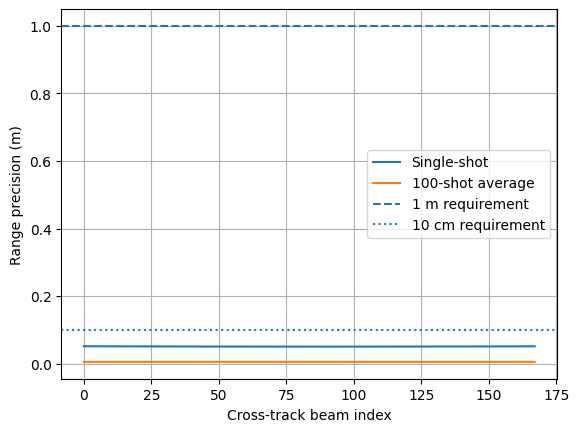

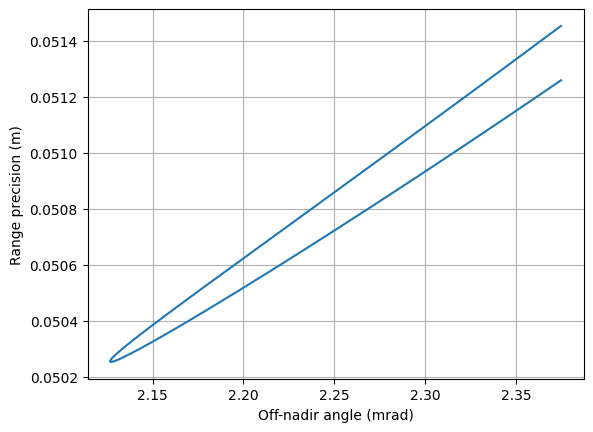

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
c = 299_792_458
h = 6.626e-34

# Mission parameters
R = 474e3
Ep = 150e-6
tau = 2e-9
theta_b = 21e-6
sigma_theta = 2e-6

D = 0.60
A_rx = np.pi*(D/2)**2

eta_tx = 0.70
eta_rx = 0.90
eta_d  = 0.90
rho_g = 0.30
Tatm = 0.90

# Swath
N = 168
swath = 1008.0
dx = swath/N
i0 = (N-1)/2
x = (np.arange(N)-i0)*dx

# Angles
theta_f = 1008/R
theta = np.sqrt(theta_f**2 + (x/R)**2)

# Wavelengths
lam = np.linspace(1035e-9, 1045e-9, N)
Eph = h*c/lam
Ntx = Ep/Eph

# Photon return
Nr = (Ntx * eta_tx * eta_rx * eta_d *
      rho_g * Tatm**2 * A_rx / (np.pi*R**2))

# Timing errors
sigma_ph = tau/np.sqrt(Nr)
sigma_geom = (2*R/c)*theta_b*np.tan(theta)
sigma_jit = (2*R/c)*sigma_theta*np.tan(theta)

sigma_t = np.sqrt(sigma_ph**2 + sigma_geom**2 + sigma_jit**2)
sigma_R = (c/2)*sigma_t

# Averaging
Navg = 100
sigma_R_avg = sigma_R/np.sqrt(Navg)

# Plots
plt.figure()
plt.plot(sigma_R, label="Single-shot")
plt.plot(sigma_R_avg, label="100-shot average")
plt.axhline(1.0, ls="--", label="1 m requirement")
plt.axhline(0.1, ls=":", label="10 cm requirement")
plt.xlabel("Cross-track beam index")
plt.ylabel("Range precision (m)")
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(theta*1e3, sigma_R)
plt.xlabel("Off-nadir angle (mrad)")
plt.ylabel("Range precision (m)")
plt.grid()
plt.show()
